# 📦 Phase 1 & 2 — Dataset EDA & Preprocessing
**Project:** Suspicious Human Activity Recognition (SHAR)

This notebook covers:
- Dataset exploration and class distribution
- Video frame extraction with OpenCV
- Feature extraction pipeline

In [20]:
import torch
print(torch.cuda.is_available())        # Should print: True
# print(torch.cuda.get_device_name(0))    # Should print: NVIDIA GeForce RTX 3050

True


In [21]:
# ── Setup & GPU Check ────────────────────────────────────
import sys, os
sys.path.insert(0, "../src")
import torch, cv2, pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path
from utils import set_seed, get_device, CLASS_NAMES, SUSPICIOUS_CLASSES

set_seed(42)
device = get_device()
print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")


✅ GPU: NVIDIA GeForce RTX 3050 6GB Laptop GPU | VRAM: 6.4 GB
PyTorch: 2.5.1+cu121
CUDA available: True
GPU: NVIDIA GeForce RTX 3050 6GB Laptop GPU


## 1.1 — Dataset Overview

In [22]:
# Scan dataset folder structure
DATA_ROOT = Path("../data/raw")
splits = ["train", "val", "test"]

# Helper to map filenames to class names
def get_class_from_name(name):
    name = name.lower()
    if "abuse" in name: return "Abuse"
    if "arrest" in name: return "Arrest"
    if "arson" in name: return "Arson"
    if "assault" in name: return "Assault"
    if "burglary" in name: return "Burglary"
    if "explosion" in name: return "Explosion"
    if "fighting" in name: return "Fighting"
    if "roadaccident" in name: return "RoadAccidents"
    if "robbery" in name: return "Robbery"
    if "shooting" in name: return "Shooting"
    if "shoplifting" in name: return "Shoplifting"
    if "stealing" in name: return "Stealing"
    if "vandalism" in name: return "Vandalism"
    if "normal" in name: return "Normal"
    if "walking_while_using_phone" in name or "walkingusingphone" in name: return "WalkingUsingPhone"
    if "walking_while_reading_book" in name or "walkingreadingbook" in name: return "WalkingReadingBook"
    if "walking" in name: return "Walking"
    if "standing_still" in name or "standingstill" in name: return "StandingStill"
    if "sitting" in name: return "Sitting"
    if "meet_and_split" in name or "meetandsplit" in name: return "MeetAndSplit"
    if "clapping" in name: return "Clapping"
    return "Unknown"

records = []
for split in splits:
    split_path = DATA_ROOT / split
    if not split_path.exists():
        print(f"⚠️  '{split}' folder not found at {split_path.absolute()}.")
        continue
    
    # Check if subdirectories exist
    subdirs = [d for d in split_path.iterdir() if d.is_dir()]
    
    if subdirs:
        # Subdirectory structure
        for cls_dir in sorted(subdirs):
            videos = list(cls_dir.glob("*.mp4"))
            records.append({"split": split, "class": cls_dir.name, "count": len(videos)})
    else:
        # Flat structure
        videos = list(split_path.glob("*.mp4"))
        if videos:
            class_counts = {}
            for v in videos:
                cls = get_class_from_name(v.name)
                class_counts[cls] = class_counts.get(cls, 0) + 1
            for cls, count in class_counts.items():
                records.append({"split": split, "class": cls, "count": count})

if not records:
    print("❌ Error: No video files found in the dataset directory. Please check the path and folder structure.")
    df = pd.DataFrame(columns=["split", "class", "count"])
else:
    df = pd.DataFrame(records)
    print("Dataset Summary:")
    summary = df.groupby("split")["count"].sum()
    print(summary)
    print(f"\nTotal unique classes found: {df['class'].nunique()}")
    print(f"Total videos across all splits: {summary.sum()}")
    display(df.head(25))


Dataset Summary:
split
test     200
train    939
val      194
Name: count, dtype: int64

Total unique classes found: 21
Total videos across all splits: 1333


,split,class,count
0,train,Abuse,40
1,train,Arrest,40
2,train,Arson,40
3,train,Assault,40
4,train,Burglary,40
5,train,Clapping,40
6,train,Explosion,40
7,train,Fighting,40
8,train,MeetAndSplit,40
9,train,Normal,100


## 1.2 — Class Distribution Plot

C:\Users\Abhinav\AppData\Local\Temp\ipykernel_19780\4187917259.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(train_df["class"], rotation=45, ha="right", fontsize=9)


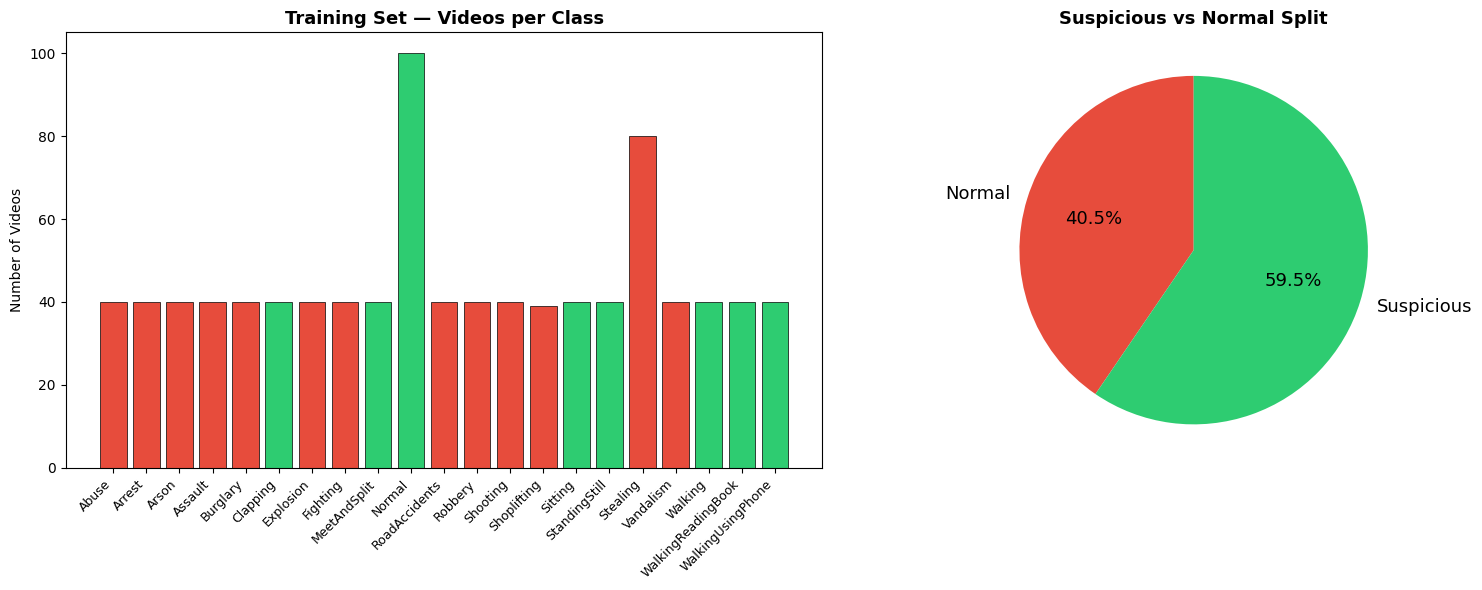

✅ Plot saved to results/plots/class_distribution.png


In [23]:
train_df = df[df["split"] == "train"].copy()
train_df["type"] = train_df["class"].apply(
    lambda x: "Suspicious" if x in SUSPICIOUS_CLASSES else "Normal")

colors = ["#e74c3c" if t == "Suspicious" else "#2ecc71"
          for t in train_df["type"].values]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart
axes[0].bar(train_df["class"], train_df["count"], color=colors, edgecolor="black", lw=0.5)
axes[0].set_xticklabels(train_df["class"], rotation=45, ha="right", fontsize=9)
axes[0].set_title("Training Set — Videos per Class", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Number of Videos")

# Pie chart — suspicious vs normal
type_counts = train_df.groupby("type")["count"].sum()
axes[1].pie(type_counts, labels=type_counts.index,
            colors=["#e74c3c", "#2ecc71"], autopct="%1.1f%%",
            startangle=90, textprops={"fontsize": 13})
axes[1].set_title("Suspicious vs Normal Split", fontsize=13, fontweight="bold")

plt.tight_layout()
plt.savefig("../results/plots/class_distribution.png", dpi=150)
plt.show()
print("✅ Plot saved to results/plots/class_distribution.png")


## 1.3 — Video Properties EDA

c:\Users\Abhinav\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Analyzing train samples: 100%|██████████| 20/20 [00:00<00:00, 51.21it/s]

Video Statistics (sample):


,frames,fps,duration_s,width,height
count,20.00,20.0,20.00,20.0,20.00
mean,708.85,30.0,23.63,472.0,576.00
std,268.44,0.0,8.95,311.9,689.46
min,294.00,30.0,9.80,320.0,240.00
25%,390.75,30.0,13.02,320.0,240.00
50%,900.00,30.0,30.00,320.0,240.00
75%,900.00,30.0,30.00,320.0,240.00
max,900.00,30.0,30.00,1080.0,1920.00


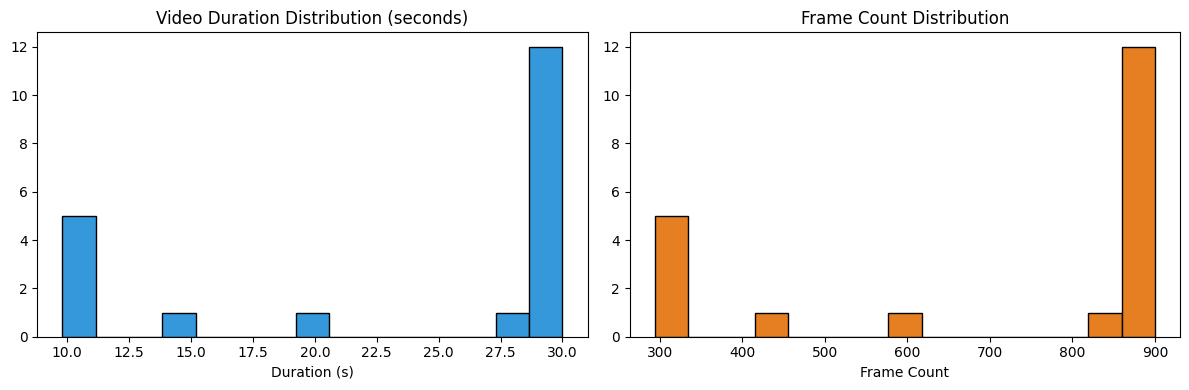

In [24]:
# Analyze video durations and frame counts
from tqdm.auto import tqdm

sample_videos = []
for split in ["train"]:
    split_path = DATA_ROOT / split
    if not split_path.exists():
        break
    
    # Handle both structures
    all_videos = []
    subdirs = [d for d in split_path.iterdir() if d.is_dir()]
    if subdirs:
        for cls_dir in subdirs:
            all_videos.extend(list(cls_dir.glob("*.mp4")))
    else:
        all_videos = list(split_path.glob("*.mp4"))

    # Sample some videos for analysis (e.g., 20 videos)
    import random
    if len(all_videos) > 20:
        sampled = random.sample(all_videos, 20)
    else:
        sampled = all_videos

    for vid in tqdm(sampled, desc=f"Analyzing {split} samples"):
        cap = cv2.VideoCapture(str(vid))
        frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        fps = cap.get(cv2.CAP_PROP_FPS)
        w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
        h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
        cap.release()
        
        if frames > 0 and fps > 0:
            sample_videos.append({
                "class": get_class_from_name(vid.name), "frames": frames,
                "fps": fps, "duration_s": frames/fps,
                "width": w, "height": h
            })

if not sample_videos:
    print("⚠️  No valid video samples found for EDA.")
    vid_df = pd.DataFrame(columns=["class", "frames", "fps", "duration_s", "width", "height"])
else:
    vid_df = pd.DataFrame(sample_videos)
    print("Video Statistics (sample):")
    display(vid_df[["frames", "fps", "duration_s", "width", "height"]].describe().round(2))

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].hist(vid_df["duration_s"], bins=15, color="#3498db", edgecolor="black")
    axes[0].set_title("Video Duration Distribution (seconds)")
    axes[0].set_xlabel("Duration (s)")
    axes[1].hist(vid_df["frames"], bins=15, color="#e67e22", edgecolor="black")
    axes[1].set_title("Frame Count Distribution")
    axes[1].set_xlabel("Frame Count")
    plt.tight_layout(); plt.show()


## 1.4 — Frame Extraction & Visualization

Extracted 10 frames from: Fighting002_x264.mp4


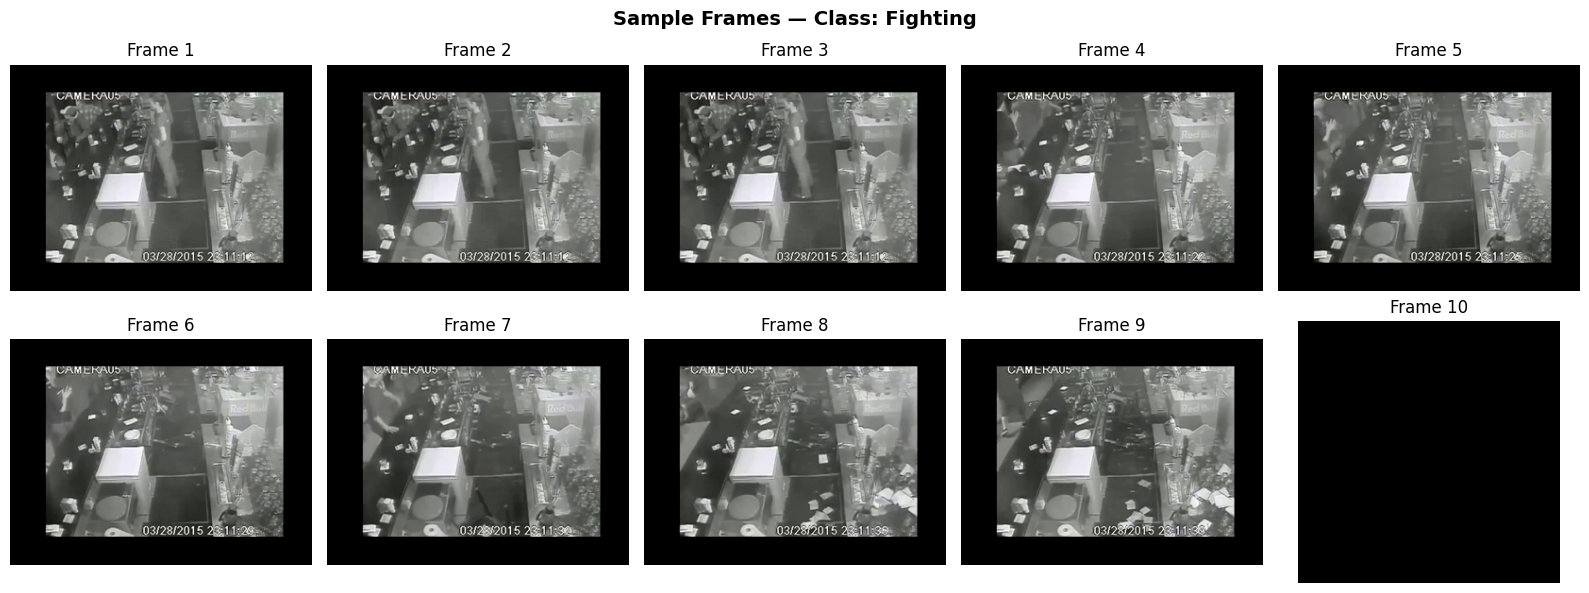

In [25]:
from dataset import extract_frames

# Show extracted frames from a sample video
sample_class = "Fighting"
# Find a video belonging to sample_class in the flat or subdir structure
sample_vid_path = None

# Search in train folder
train_path = DATA_ROOT / "train"
if train_path.exists():
    # Try flat structure first
    videos = list(train_path.glob("*.mp4"))
    for v in videos:
        if get_class_from_name(v.name) == sample_class:
            sample_vid_path = v
            break
    
    # Try subdirectory if not found
    if not sample_vid_path:
        class_dir = train_path / sample_class
        if class_dir.exists():
            vids = list(class_dir.glob("*.mp4"))
            if vids:
                sample_vid_path = vids[0]

if sample_vid_path:
    vid = str(sample_vid_path)
    frames = extract_frames(vid, num_frames=10)
    print(f"Extracted {len(frames)} frames from: {sample_vid_path.name}")
    fig, axes = plt.subplots(2, 5, figsize=(16, 6))
    for i, (ax, frame) in enumerate(zip(axes.flat, frames)):
        ax.imshow(frame)
        ax.set_title(f"Frame {i+1}")
        ax.axis("off")
    fig.suptitle(f"Sample Frames — Class: {sample_class}", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.savefig("../results/plots/sample_frames.png", dpi=100)
    plt.show()
else:
    print(f"⚠️  No videos found for class '{sample_class}'. Please check dataset.")


## 1.5 — DataLoader Test

In [26]:
from dataset import get_dataloader
from torchvision.utils import make_grid

train_loader, ds = get_dataloader("../data/raw", "train", batch_size=4, num_workers=0)
print(f"Dataset size: {len(ds)} videos")
print(f"Batches per epoch: {len(train_loader)}")

# Inspect a batch
frames, labels, paths = next(iter(train_loader))
print(f"\nBatch frames shape: {frames.shape}")  # (B, T, 3, 224, 224)
print(f"Labels: {[CLASS_NAMES[l] for l in labels.tolist()]}")
print("✅ DataLoader working correctly!")


  ✅ Loaded 21 class names from lable.txt
  [train] 939 videos | 21 classes | from train/
Dataset size: 939 videos
Batches per epoch: 235

Batch frames shape: torch.Size([4, 20, 3, 224, 224])
Labels: ['Arrest', 'MeetAndSplit', 'Abuse', 'Sitting']
✅ DataLoader working correctly!
